**Problem 1 (20 pontos)**

Use relational notation and construct a function to describe the periodic signal shown below. 

Analyze the results and provide the proper comments.

<p align="center">
  <img src="img/img_problem_1.png" width="500"/>
</p>

*Relational notation*

$$x(t)=
\begin{cases}
   5 \tau - 5, 0 \le \tau \lt 2, \\  
  -5 \tau + 15, 2 \le \tau \lt 4,    
\end{cases} \text{with } \tau = t \bmod 4 \text{ and } x(t+4)=x(t) 
$$

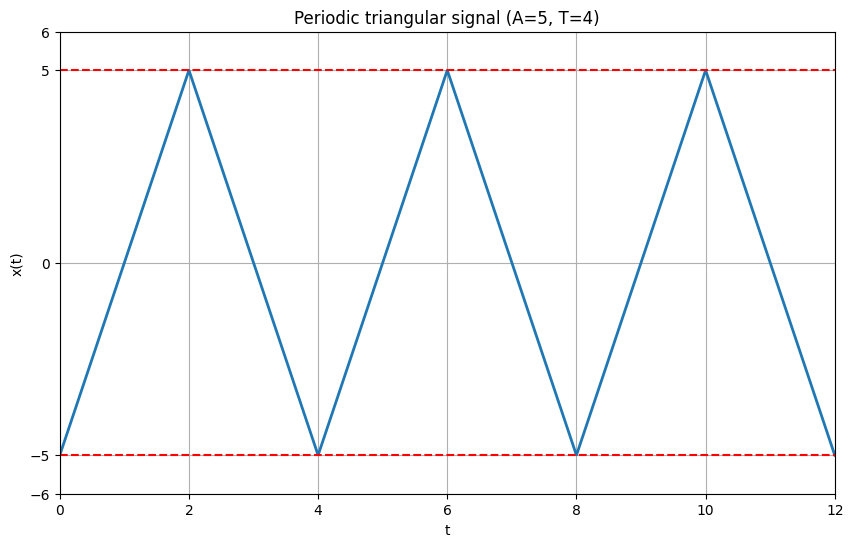

In [39]:
# libraries
import numpy as np
import matplotlib.pyplot as plt

# Periodic triangle
def x_tri(t, T=4.0):
    tau = np.mod(t, T)
    return np.where(tau < 2.0, 5.0*tau - 5.0, -5.0*tau + 15.0) 

# Simulation
t = np.linspace(0, 12, 2000)
x = x_tri(t)

# Plot
plt.figure(figsize=(10, 6))
plt.plot(t, x, linewidth=2)
plt.title("Periodic triangular signal (A=5, T=4)")
plt.xlabel("t")
plt.ylabel("x(t)")
plt.ylim(-6, 6)
plt.hlines([5, -5], xmin=0, xmax=12, colors='r', linestyles='--', linewidth=1.5)
plt.yticks([-6, -5, 0, 5, 6]) 
plt.xlim(0, 12)
plt.grid()
plt.show()


*Comments*

The periodic triangular signal defined by

$$x(t)=
\begin{cases}
   5 \tau - 5, 0 \le \tau \lt 2, \\  
  -5 \tau + 15, 2 \le \tau \lt 4,    
\end{cases} \text{with } \tau = t \bmod 4 \text{ and } x(t+4)=x(t) 
$$
with a amplitude \(A=5\) and period \(T=4\).

It rises linearly from \-5 to \+5 on \[0, 2] (slope \+5) and falls back to \-5 on \[2, 4] (slope \-5), repeating every four units of $t$.

The signal is continuous but not differentiable at $t$=0, 2, 4. It crosses zero at $t$=1+4k and $t$=3+4k, attains +5 at $t$=2+4k, and -5 at $t$=4k, for $k$ $\in$ $\mathbb{Z}$.




**Problem 2 (40 pontos)**

Suppose the signal described in Problem 01 is shifted by the addition of a 5 V DC level. Furthermore, a uniformly distributed noise is added in the interval [-3, 3].

The resulting signal is then subjected to a low-pass filter with time constant τ. 

Find a good value for τ by testing time constant values of 10; 1; 0.1; and 0.01 (you can also try other values).

Use a step of 0.01 for the simulation. 

Analyze the results and provide the proper comments.

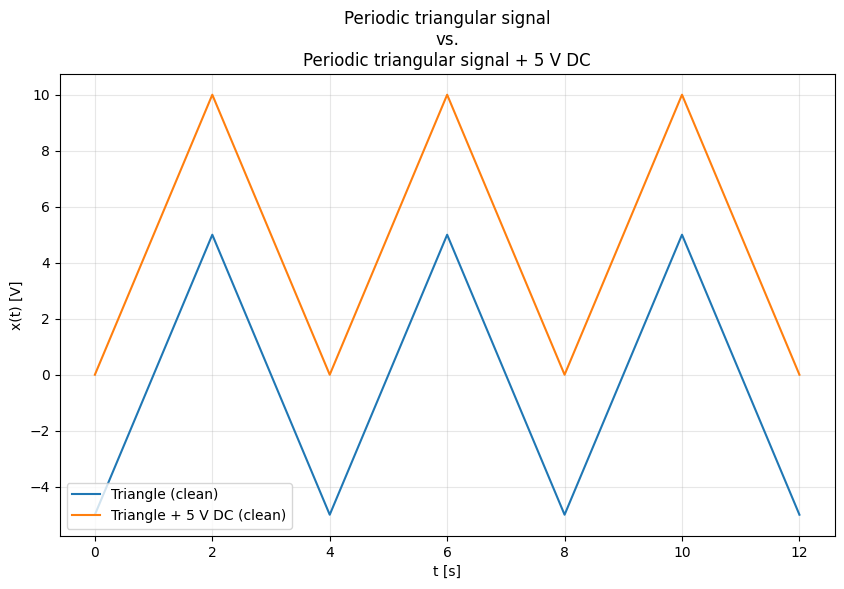

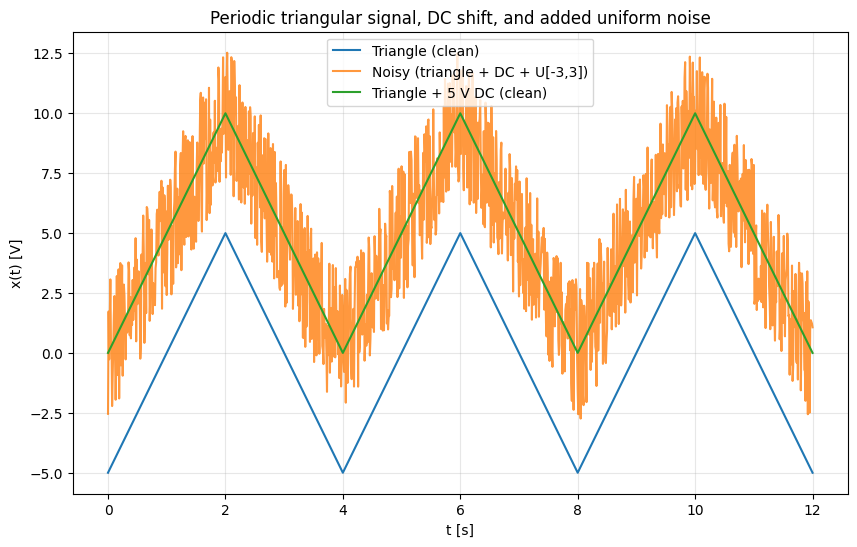

In [3]:
'''
Periodic triangular signal plus triangular signal with addittion of a 5 V DC and uniform noise
- First plot indicates periodic triangular signal plus triangular signal with addittion of a 5 V DC (without noise);
- Second plot indicates periodic triangular signal plus triangular signal with addittion of a 5 V DC with ubiformly
distribuided noise);
'''
# libraries
import numpy as np
import matplotlib.pyplot as plt

# Set seed due to random noise
np.random.seed(7)

# Base triangular wave parameters
A = 5.0   # amplitude
T = 4.0   # period (seconds)

# Simulation parameters
dt = 0.01             # time step
t_end = 12.0          # simulate 3 periods
t = np.arange(0.0, t_end + dt/2, dt)  # ensure inclusive end

# Periodic triangle
def x_tri(t, A=5.0, T=4.0):
    tau = np.mod(t, T)
    return np.where(tau < 2.0, 5.0*tau - 5.0, -5.0*tau + 15.0) 

# Noise and DC-shift
DC = 5.0                   # 5 V DC shift
noise_low = -3.0
noise_high = 3.0

# Build the shifted noisy signal
x_clean = x_tri(t, A=A, T=T)          # base triangle in [−5, +5]
x_shift = x_clean + DC                 # add 5 V DC level
noise = np.random.uniform(noise_low, noise_high, size=t.shape)
x_noisy = x_shift + noise              # final noisy input to the filter

# Plot the Periodic triangular signal vs. shifted (Merge)
plt.figure(figsize=(10,6))
plt.plot(t, x_clean, label="Triangle (clean)")
plt.plot(t, x_shift, label="Triangle + 5 V DC (clean)")
plt.xlabel("t [s]")
plt.ylabel("x(t) [V]")
plt.title("Periodic triangular signal\nvs.\nPeriodic triangular signal + 5 V DC")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# Plot the clean vs. shifted vs. noisy (Merge)
plt.figure(figsize=(10,6))
plt.plot(t, x_clean, label="Triangle (clean)")
plt.plot(t, x_noisy, label="Noisy (triangle + DC + U[-3,3])", alpha=0.8)
plt.plot(t, x_shift, label="Triangle + 5 V DC (clean)")
plt.xlabel("t [s]"); plt.ylabel("x(t) [V]")
plt.title("Periodic triangular signal, DC shift, and added uniform noise")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

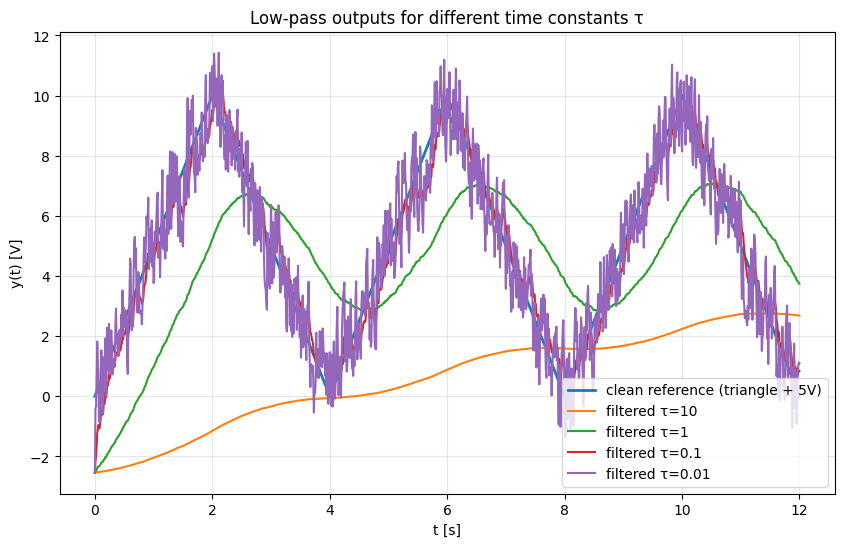

In [14]:
'''
Low-pass filter with tau suggested by professor
'''

# First‑order low‑pass filter (time constant tau)
def lowpass_first_order(x, tau, dt, y0=None):
    if tau <= 0:
        raise ValueError("tau must be positive")
    alpha = dt / (tau + dt)
    y = np.empty_like(x, dtype=float)
    y[0] = x[0] if y0 is None else y0
    for n in range(1, len(x)):
        y[n] = y[n-1] + alpha * (x[n] - y[n-1])
    return y, alpha

# Passing filter 
taus = [10.0, 1.0, 0.1, 0.01]  
filtered = {}
alphas = {}
for tau in taus:
    y, a = lowpass_first_order(x_noisy, tau=tau, dt=dt)
    filtered[tau] = y
    alphas[tau] = a

# Visualize overlays for the different taus against the clean (shifted) reference
plt.figure(figsize=(10,6))
plt.plot(t, x_shift, linewidth=2, label="clean reference (triangle + 5V)")
for tau in taus:
    plt.plot(t, filtered[tau], label=f"filtered τ={tau:g}")
plt.xlabel("t [s]"); plt.ylabel("y(t) [V]")
plt.title("Low-pass outputs for different time constants τ")
plt.grid(True, alpha=0.3); plt.legend(loc="best")
plt.show()

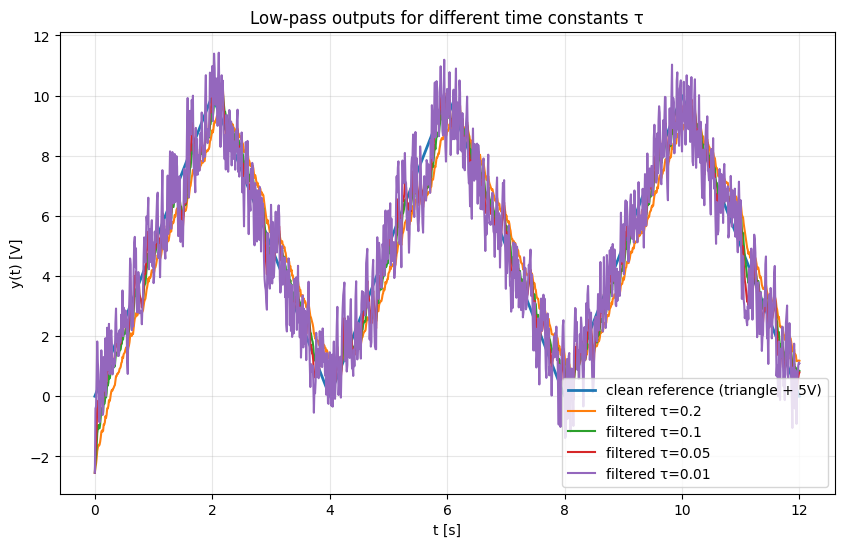

In [ ]:
'''
Low-pass filter with tau values adjusted by previous results
'''
# First‑order low‑pass filter (time constant tau)
def lowpass_first_order(x, tau, dt, y0=None):
    if tau <= 0:
        raise ValueError("tau must be positive")
    alpha = dt / (tau + dt)
    y = np.empty_like(x, dtype=float)
    y[0] = x[0] if y0 is None else y0
    for n in range(1, len(x)):
        y[n] = y[n-1] + alpha * (x[n] - y[n-1])
    return y, alpha

# Passing filter 
taus = [0.2, 0.1, 0.05, 0.01]  
filtered = {}
alphas = {}
for tau in taus:
    y, a = lowpass_first_order(x_noisy, tau=tau, dt=dt)
    filtered[tau] = y
    alphas[tau] = a

# Visualize overlays for the different taus against the clean (shifted) reference
plt.figure(figsize=(10,6))
plt.plot(t, x_shift, linewidth=2, label="clean reference (triangle + 5V)")
for tau in taus:
    plt.plot(t, filtered[tau], label=f"filtered τ={tau:g}")
plt.xlabel("t [s]"); plt.ylabel("y(t) [V]")
plt.title("Low-pass outputs for different time constants τ")
plt.grid(True, alpha=0.3); plt.legend(loc="best")
plt.show()


*Comments*

In the first part of Problem 2, as expected, the addition of a 5 V DC component shifts the periodic triangular signal upward, while its amplitude and period remain unchanged. Furthermore, when a uniformly distributed noise is added to the 5 V-shifted triangular signal, the resulting waveform becomes noisy but preserves the same fundamental characteristics of the original clean triangular signal.

When the recommended low-pass filters were applied, with time constants $\tau = [10.0, 1.0, 0.1, 0.01]$, it was observed that $\tau$ values of 0.1 and 0.01 provided a good fit to the original signal, whereas filters with $\tau = 10.0$ and $\tau = 1.0$ did not reproduce the signal effectively.


To further investigate intermediate values of $\tau$ based on the previous analysis, additional tests were performed using $\tau = [0.2, 0.05]$. The results show that $\tau = 0.2$ does not fit the original signal as well as the previously tested values, whereas the filter with $\tau = 0.05$ demonstrates excellent performance, comparable to that obtained with $\tau = 0.01$.

**Problem 3 (40 pontos)**

Simulate the system, in the time interval between 0 and 15 seconds.

<p align="center">
  <img src="img/img_problem_2.png" width="500"/>
</p>

Data:

- Deterministic input signals x1(t) = sin(0,5 t) and x2(t) = cos(0,5 t).

- The initial conditions are zero.

 a) Show the results of the system simulation for y1(t) and y2(t).

 b) Repeat the system simulation considering the addition of uniform noise with zero mean and variance 1/3 to both inputs x1(t) and x2(t).

 c) Pass the noisy outputs through low-pass filters with time constants τ = 0.5; 0.8, and 2.

 d) Provide comments on the achieved results.